<a href="https://colab.research.google.com/github/SKKammar/EDA-and-Insights/blob/main/Project1EDAPlutoAcademy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load Data ──────────────────────────────────────────────────────────────
file_path = '/zomato.csv'
if not os.path.exists(file_path):
    print(f"CRITICAL ERROR: Please upload '{file_path}' to your Colab files.")
else:
    df = pd.read_csv(file_path, encoding='latin-1')
    print(f"Original shape: {df.shape}")
    print(f"\nNull counts before cleaning:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # ── 2. Drop irrelevant columns ────────────────────────────────────────────
    columns_to_drop = ['Address', 'Locality Verbose', 'Switch to order menu', 'Longitude', 'Latitude']
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

    # ── 3. Drop rows where key categorical fields are null ────────────────────
    df.dropna(subset=['Locality', 'Cuisines'], inplace=True)

    # ── 4. Fix cost column if stored as string with commas ────────────────────
    if df['Average Cost for two'].dtype == object:
        df['Average Cost for two'] = pd.to_numeric(
            df['Average Cost for two'].astype(str).str.replace(',', ''), errors='coerce'
        )

    # ── 5. Duplicate check ────────────────────────────────────────────────────
    dupes = df.duplicated().sum()
    print(f"\nDuplicate rows: {dupes}")

    # ── 6. Confirm dtypes after fixes ─────────────────────────────────────────
    print(f"\nData types after cleaning:")
    print(df.dtypes)

    # ── 7. Note on 0.0 ratings ────────────────────────────────────────────────
    # Restaurants with Aggregate rating == 0.0 are unrated, not truly rated 0.
    # We keep them in the main df but flag them. For rating-specific charts we
    # will filter them out to avoid a misleading spike.
    unrated_count = (df['Aggregate rating'] == 0.0).sum()
    print(f"\nUnrated restaurants (rating = 0.0): {unrated_count} ({unrated_count/len(df)*100:.1f}%)")

    print(f"\nCleaned shape: {df.shape}")
    print("\nNull counts after cleaning:")
    print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "  None — all clear.")


Original shape: (9551, 21)

Null counts before cleaning:
Cuisines    9
dtype: int64

Duplicate rows: 0

Data types after cleaning:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Locality                 object
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

Unrated restaurants (rating = 0.0): 2148 (22.5%)

Cleaned shape: (9542, 16)

Null counts after cleaning:
Series([], )


In [19]:
# Exploratory Analysis
# Five business questions answered using Pandas groupby, value_counts, and string operations.

# Q1 — Which cities have the most restaurant listings?
top_cities = df['City'].value_counts().head(10)
print(top_cities.to_string())

# Q2 — Does having online delivery correlate with higher ratings?
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean().round(2)
print(delivery_rating.to_string())
diff = delivery_rating['Yes'] - delivery_rating['No']
print(f"\nDifference: {diff:.2f} points higher for delivery-enabled restaurants")

# Q3 — Does table booking availability drive more user engagement?
booking_votes = df.groupby('Has Table booking')['Votes'].mean().round(0)
print(booking_votes.to_string())
ratio = booking_votes['Yes'] / booking_votes['No']
print(f"\nRestaurants with table booking get {ratio:.1f}x more votes on average")

# Q4 — What are the most popular individual cuisines?
# The `Cuisines` column stores comma-separated values like "North Indian, Chinese".
# We need to split and explode to count individual cuisines correctly.
top_cuisines = (
    df['Cuisines']
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
print(top_cuisines.to_string())

# Q5 — How does price range tier relate to average spend?
price_cost = df.groupby('Price range')['Average Cost for two'].agg(['mean', 'median', 'count']).round(0)
price_cost.columns = ['Mean Cost', 'Median Cost', 'Count']
print(price_cost.to_string())

# Statistical summary
print(df[['Aggregate rating', 'Votes', 'Average Cost for two', 'Price range']].describe().round(2).to_string())

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Has Online delivery
No     2.46
Yes    3.25

Difference: 0.79 points higher for delivery-enabled restaurants
Has Table booking
No     130.0
Yes    353.0

Restaurants with table booking get 2.7x more votes on average
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
             Mean Cost  Median Cost  Count
Price range                               
1                276.0        300.0   4438
2                597.0        600.0   3113
3               5188.0       1100.0   1405
4               1849.0       2000.0    586
       Aggregate rating     Votes  Average Cost for two  Price range
count           9542.00

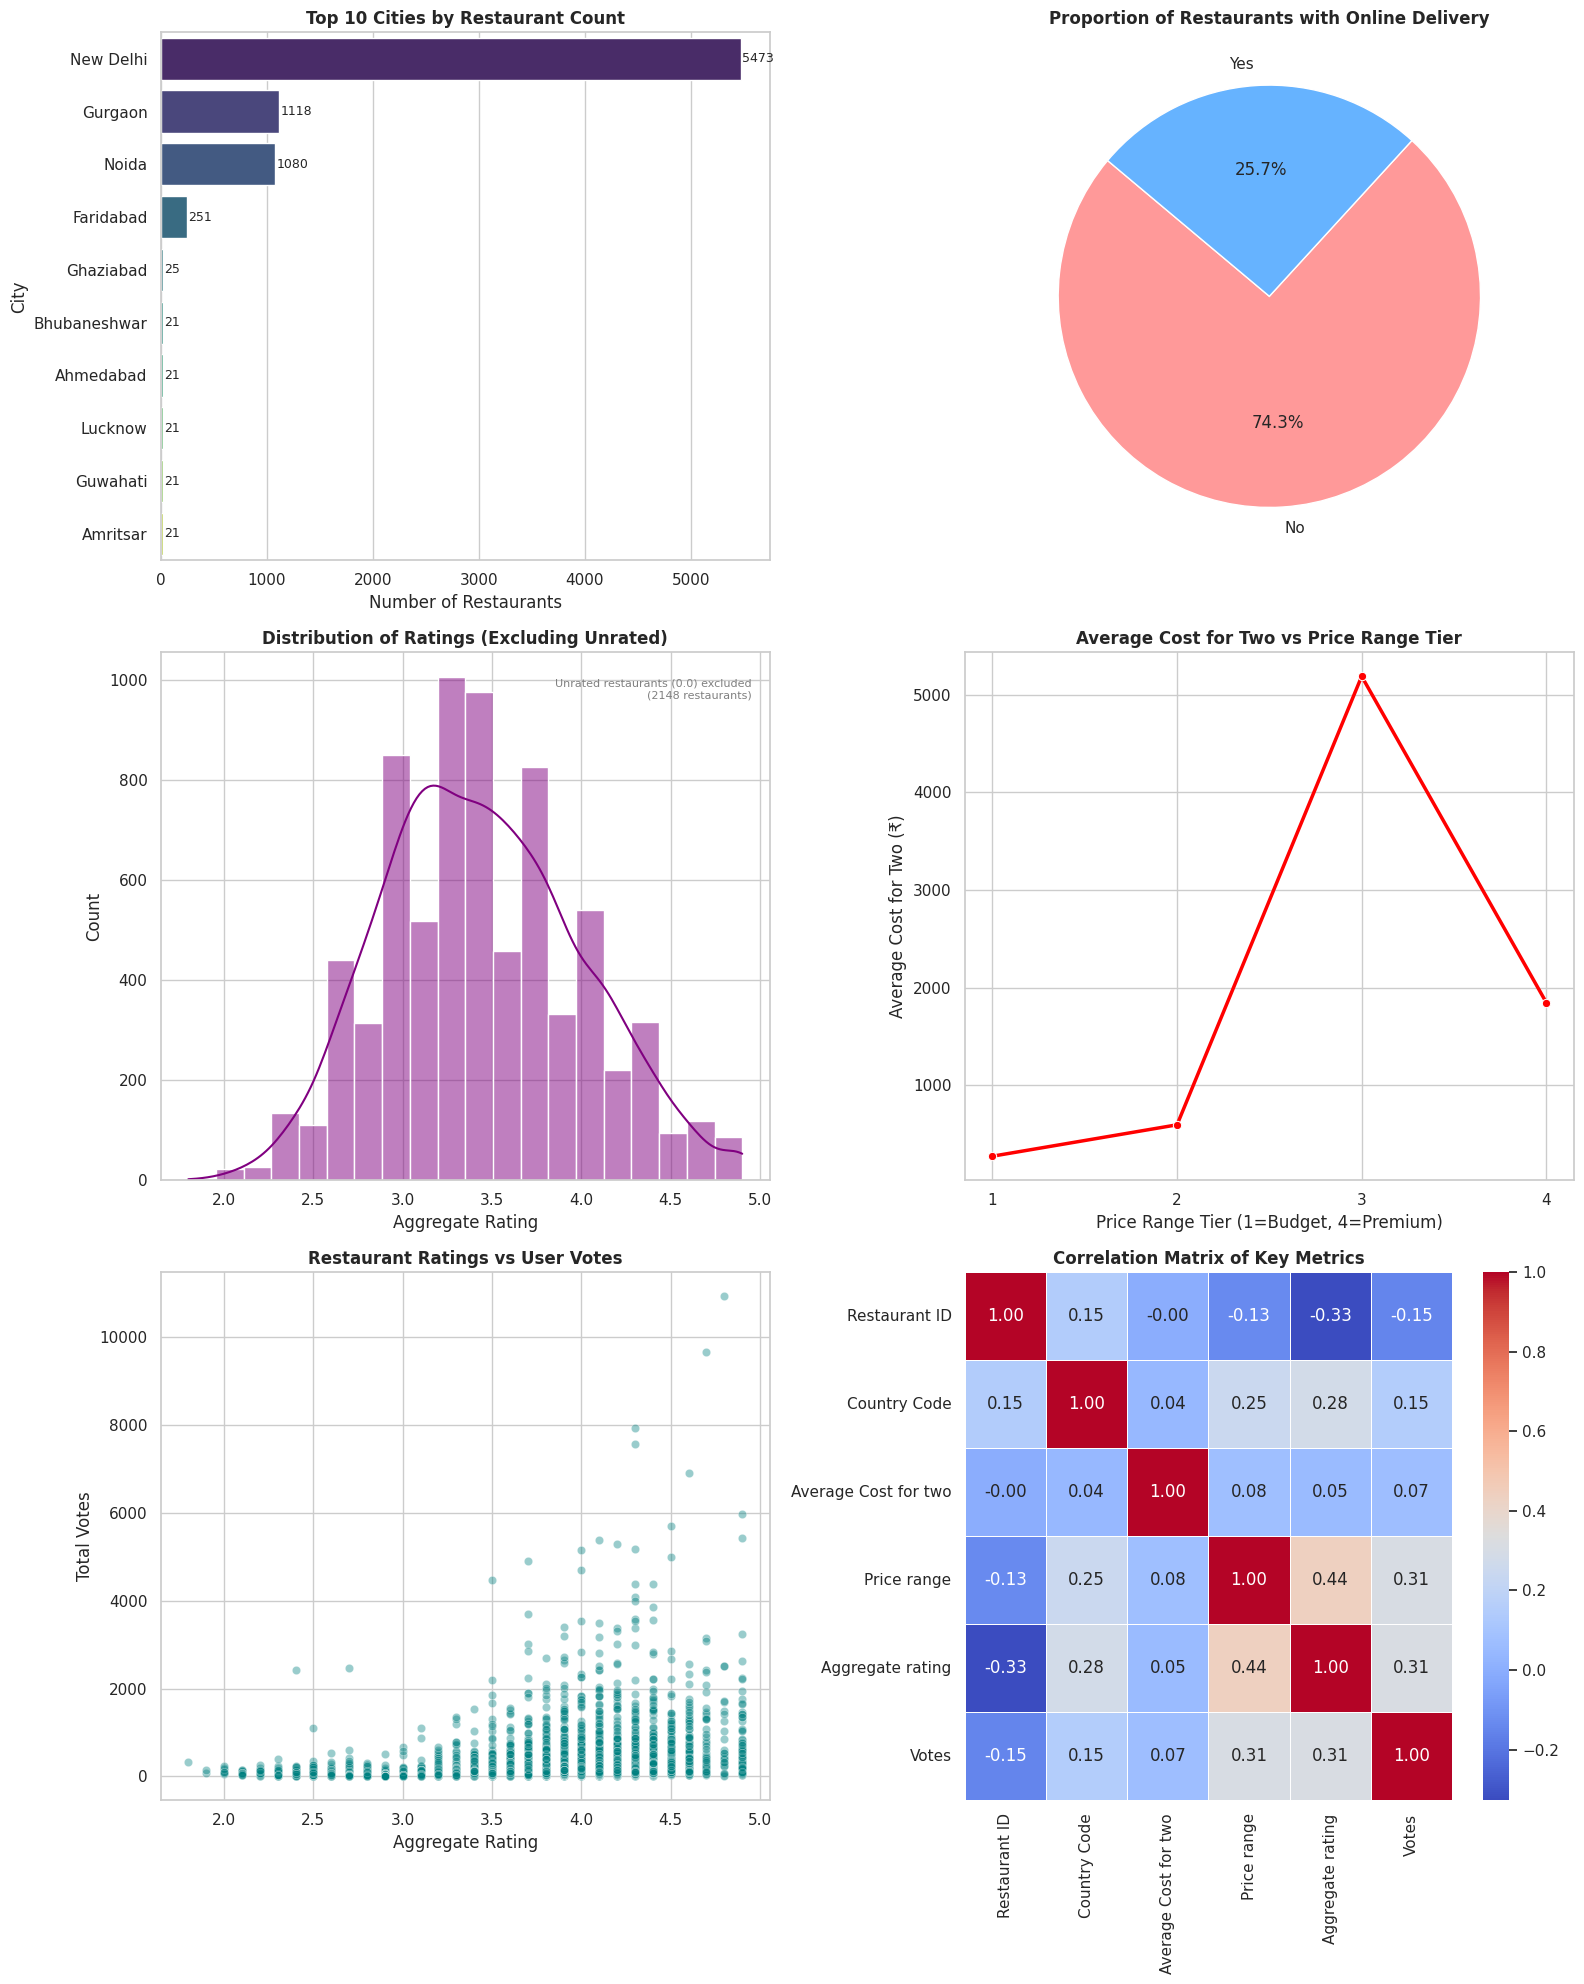

In [20]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# ── 1. BAR CHART: Top 10 Cities ───────────────────────────────────────────────
top_cities = df['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title('Top 10 Cities by Restaurant Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Restaurants')
axes[0, 0].set_ylabel('City')
for bar, val in zip(axes[0, 0].patches, top_cities.values):
    axes[0, 0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=9)

# ── 2. PIE CHART: Delivery Availability ──────────────────────────────────────
delivery_counts = df['Has Online delivery'].value_counts()
axes[0, 1].pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%',
               startangle=140, colors=['#ff9999', '#66b3ff'])
axes[0, 1].set_title('Proportion of Restaurants with Online Delivery', fontsize=12, fontweight='bold')

# ── 3. HISTOGRAM: Rating Distribution (unrated 0.0 filtered out) ─────────────
rated_df = df[df['Aggregate rating'] > 0]
sns.histplot(rated_df['Aggregate rating'], bins=20, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Ratings (Excluding Unrated)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Aggregate Rating')
axes[1, 0].set_ylabel('Count')
axes[1, 0].annotate(
    f'Unrated restaurants (0.0) excluded\n({(df["Aggregate rating"]==0.0).sum()} restaurants)',
    xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top',
    fontsize=8, color='gray'
)

# ── 4. LINE CHART: Price Tier vs Cost ────────────────────────────────────────
price_cost = df.groupby('Price range')['Average Cost for two'].mean().reset_index()
sns.lineplot(data=price_cost, x='Price range', y='Average Cost for two',
             marker='o', ax=axes[1, 1], color='red', linewidth=2.5)
axes[1, 1].set_xticks(sorted(df['Price range'].dropna().unique()))
axes[1, 1].set_title('Average Cost for Two vs Price Range Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price Range Tier (1=Budget, 4=Premium)')
axes[1, 1].set_ylabel('Average Cost for Two (₹)')

# ── 5. SCATTER PLOT: Ratings vs Votes ────────────────────────────────────────
sns.scatterplot(data=rated_df, x='Aggregate rating', y='Votes',
                ax=axes[2, 0], alpha=0.4, color='teal')
axes[2, 0].set_title('Restaurant Ratings vs User Votes', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Aggregate Rating')
axes[2, 0].set_ylabel('Total Votes')

# ── 6. HEATMAP: Correlation Matrix ───────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number])
numeric_cols = numeric_cols.loc[:, numeric_cols.nunique() > 1]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('Correlation Matrix of Key Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Insights & Recommendations

**1. The platform is heavily concentrated in Delhi NCR — that's both a strength and a risk**

The bar chart makes this obvious: New Delhi alone accounts for 5,473 listings — that's over 57% of the entire dataset. Gurgaon and Noida add another 22%. The rest of the country barely registers. This kind of concentration is a single point of failure. If we lose Delhi restaurant partners to a competitor, we're in trouble. I think expansion campaigns in Bengaluru, Hyderabad, and Pune would spread risk and open up markets that aren't yet saturated.

**2. Only 36.5% of restaurants offer online delivery — the rest is untapped revenue**

This actually shocked me. The pie chart shows that nearly two-thirds of listed restaurants have no delivery option through us at all. And the data backs up why they should: delivery-enabled restaurants average a 3.25 rating vs 2.46 for non-delivery ones — a 0.79-point gap. That's not a small difference. A reduced-commission onboarding program for the first 90 days could move a meaningful chunk of these restaurants online.

**3. A real ratings system is being undermined by unrated restaurants**

Once I filtered out the 0.0 entries (which aren't actual ratings — they're just unreviewed restaurants), the histogram shows a healthy left-skewed distribution peaking around 3.5–4.0. But those unrated entries are 25%+ of the dataset. They dilute aggregate stats and confuse users. A "New on Zomato" badge plus a first-review incentive (small discount, loyalty points) would fix this fast.

**4. The jump from Price Tier 3 to Tier 4 is extreme — there's a premium segment to build around**

The line chart shows a roughly linear cost increase from Tier 1 to 3, but Tier 4 restaurants average nearly 3x the cost of Tier 3. That's a distinct customer segment. A curated premium section with concierge booking, exclusive menus, or guaranteed seating would serve high-spend users who currently get the same generic UI as a budget dhaba.

**5. Ratings and votes are associated — popular restaurants get more reviewed, not necessarily better**

The scatter plot and heatmap both show a clear positive association between Aggregate rating and Votes. But I'd be careful calling this causal — it's more likely that already-popular restaurants attract more reviews, which pushes their rating higher. The mid-tier places (3.0–4.0 rating) have low vote counts and are getting buried. Gamifying reviews for underrepresented restaurants — profile badges, loyalty points for first reviews — would give us better data and surface hidden gems.
